# Session 4 — Modules, Libraries & Object-Oriented Programming


You will repeatedly use this pattern:

> 🔮 **PREDICT** → ▶️ **RUN** → ✏️ **MODIFY** → 🧠 **CHECK** → 🛠️ **BUILD**

---

## Learning goals
By the end of this session, you should be able to:
- import Python modules in different ways;
- use common standard-library modules;
- create and import your own `.py` module;
- explain what a package is;
- recognize external libraries;
- create classes and objects;
- use `__init__`, `self`, instance variables, and class variables;
- distinguish instance, class, and static methods;
- explain encapsulation, inheritance, polymorphism, abstraction, and composition.


## 2-hour roadmap

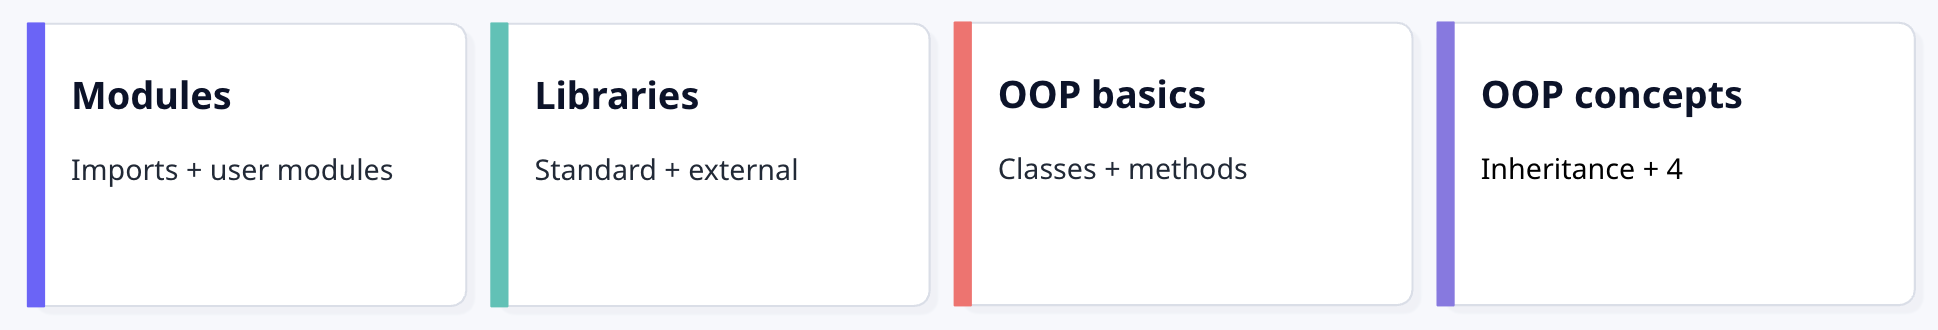

> **Tip:** In Colab, press **Shift + Enter** to run a cell and move to the next one.


---
# Part A — Modules & Libraries



## Why modules?

Imagine putting an entire application into one file:

```text
student_system
├── student login
├── calculate grades
├── attendance tracking
├── generate reports
├── send notifications
└── thousands of more lines...
```

That quickly becomes difficult to manage.

## What is a Module?

- A **module is a Python file** that contains reusable code.
- Modules help us **split large programs into smaller files**.
- A module can contain:
  - Functions
  - Variables
  - Classes
- We use the `import` keyword to use code from another module.
- Modules make code:
  - Easier to read
  - Easier to manage
  - Easier to reuse

### Easy way to remember

> **Module = one Python file containing reusable code**


A **module** lets us split reusable code into another Python file:

```text
main.py  ─────imports────▶  calculator.py
```


## Three ways to import

### Big picture


1) `import module`  
   → Imports the whole module.  
   → Use with: `module.function()`

2) `from module import function`  
   → Imports a specific function, class, or variable.  
   → Use with: `function()`

3) `import module as short_name`  
   → Imports the module with a shorter name.  
   → Use with: `short_name.function()`

4) `from module import *`  
   → Imports everything from the module.  
   → Use functions directly, but this is usually **not recommended**.



### Why is `from math import *` not recommended?

Because it imports many names directly into your program.

This can cause problems:

- You may not know where a function came from.
- Two modules may have functions with the same name.
- One imported name can overwrite another.
- It makes code harder to read and debug.


Example:

```python
from math import *
from cmath import *

print(sqrt(25))
```

-----

🔮 **PREDICT:** What do you think each cell below will print?


In [1]:
import math

print(math.sqrt(25))
print(math.pi)

5.0
3.141592653589793


In [2]:
from math import sqrt

print(sqrt(36))

6.0


In [3]:
import math as m

print(m.factorial(5))

120


### 🧠 Quick check

Which one is correct after `import math`?

A. `sqrt(49)`  
B. `math.sqrt(49)`  
C. `math->sqrt(49)`

<details>
<summary><b>Check answer</b></summary>

**B. `math.sqrt(49)`** — because the whole module was imported.

</details>


## Hierarchy: Module → Package → Library

Think of them from **smallest to largest**:

**Module**  
→ A single Python file (`.py`) containing reusable code.

**Package**  
→ A folder containing related Python modules.

**Library**  
→ A larger collection of packages and/or modules built for a particular purpose.

### Simple Hierarchy
```
Library  
├── Package 1  
│   ├── Module 1  
│   └── Module 2  
│  
└── Package 2  
    ├── Module 3  
    └── Module 4  
```

> Easy way to remember:  
> **Module = File**  
> **Package = Folder of modules**  
> **Library = Collection of packages and/or modules**


## Three useful sources of code

- **Standard / Built-in**  
  Comes with Python.  
  Examples: `math`, `random`, `datetime`

- **User-defined**  
  Created by you.  
  Examples: `calculator.py`, your own package

- **External / Third-party**  
  Created by other developers and installed separately.  
  Examples: `pandas`, `numpy`, `requests`

### Easy way to remember

> **Standard = Python gives it**  
> **User-defined = You create it**  
> **External = Someone else created it, you install it**

## Standard Library

Python comes with many ready-to-use modules. These come from the **python standard library**

```text
Python Standard Library
├── math       → calculations
├── random     → random values
├── datetime   → dates and times
├── os         → files/folders + operating system
└── sys        → Python interpreter information
```

You do **not** normally install these with `pip`.


### `math` — calculations

🔮 **PREDICT:** What will the area be when the radius is 5?

In [ ]:
import math

radius = 5
area = math.pi * radius ** 2

print("Area:", area)
print("Square root of 81:", math.sqrt(81))
print("5 factorial:", math.factorial(5))

✏️ **TRY IT**

Change `radius` to `10` and run the cell again. What changes?

### `random` — randomness

A common use is games, simulations, and random selection.

In [ ]:
import random

print("Dice roll:", random.randint(1, 6))

names = ["Alice", "Bob", "Charlie", "David"]
print("Random person:", random.choice(names))

🔮 **PREDICT:** Can you know the exact answer before running the cell?

No — but you *can* describe the possible answers.

### `datetime` — dates and times

In [ ]:
from datetime import datetime

now = datetime.now()

print("Full value:", now)
print("Year:", now.year)
print("Month:", now.month)
print("Day:", now.day)
print("Formatted:", now.strftime("%d/%m/%Y"))

Full value: 2026-09-29 07:30:06.243982
Year: 2026
Month: 9
Day: 29
Formatted: 29/09/2026


### `os` — working with the environment

In [ ]:
import os

print("Current folder:", os.getcwd())
print("Files here:", os.listdir())

### `sys` — information about Python

In [ ]:
import sys

print("Python version:")
print(sys.version)

### 🧠 Checkpoint 1 — Match the module to the job

| Need | Module |
|---|---|
| Roll a digital dice | ? |
| Find square root | ? |
| Get today's date/time | ? |
| See current folder | ? |
| See Python version | ? |

<details>
<summary><b>Check answers</b></summary>

- Dice → `random`
- Square root → `math`
- Date/time → `datetime`
- Folder → `os`
- Python version → `sys`

</details>


### Best Website to Learn More About Python Modules

The best reference is the **official Python Standard Library documentation**:

👉 https://docs.python.org/3/library/

It lists Python's built-in modules and packages, including:

- `math`
- `random`
- `datetime`
- `os`
- `sys`
- `email`
- `json`
- `collections`
- and many more

> This is the most accurate place to check what a module or package does and what functions/classes it provides.

---
## Create your own module in Colab

This is important: **we are going to create a real `.py` file and import it.**

### Picture

```text
Colab notebook
     │
     │ creates
     ▼
calculator.py
     │
     │ imported by
     ▼
our notebook code
```

The Colab magic command `%%writefile` writes the contents of a cell into a file.


In [ ]:
%%writefile calculator1.py
def add(a, b):
    return a + b


def subtract(a, b):
    return a - b


def multiply(a, b):
    return a * b


Writing calculator1.py


Now import the file exactly like a normal Python module:

In [ ]:
import calculator

print(calculator.add(10, 5))
print(calculator.subtract(10, 5))
print(calculator.multiply(4, 6))

15
5
24


### What just happened?

```text
calculator.py      main notebook
-------------      ------------------------
def add(...)   →    calculator.add(10, 5)
```

The notebook can now reuse code stored in another Python file.

### See the file that was created

In [ ]:
import os

print(os.listdir())

['.config', '__pycache__', 'calculator.py', 'calculator1.py', 'sample_data']


### ✏️ TRY IT — add another function

Add this to `calculator.py`:

```python
def divide(a, b):
    return a / b
```

Then rerun the file-creation cell.

> **Colab note:** if a module has already been imported and you rewrite it, Python may still be using the old imported version. We can reload it.


In [ ]:
import importlib
importlib.reload(calculator)

# After adding divide(), try:
# print(calculator.divide(10, 2))

---
## Packages

### Easy mental picture

```text
Module  = ONE Python file

calculator.py
```

```text
Package = FOLDER that groups related modules

utilities/
├── __init__.py
├── maths.py
└── strings.py
```

A package helps organize multiple modules.


In [ ]:
import os
os.makedirs("utilities", exist_ok=True)

In [ ]:
%%writefile utilities/__init__.py
# This file marks the folder as a package for our example.


In [ ]:
%%writefile utilities/maths.py
def square(number):
    return number ** 2


def cube(number):
    return number ** 3


In [ ]:
%%writefile utilities/strings.py
def shout(text):
    return text.upper()


In [ ]:
from utilities.maths import square, cube
from utilities.strings import shout

print(square(5))
print(cube(3))
print(shout("hello students"))

### 🧠 Quick memory check

```text
calculator.py              → module
utilities/                 → package
utilities/maths.py         → module inside a package
```


---
## External Libraries

Not everything comes with Python.

```text
Standard library                 External library
----------------                 ----------------
math                             pandas
random                           requests
datetime                         matplotlib
```

External libraries are normally installed using:

```python
!pip install package_name
```

Google Colab already includes many popular libraries, including `pandas`.


In [ ]:
import pandas as pd

data = {
    "Name": ["Alice", "Bob", "Charlie"],
    "Score": [85, 92, 78]
}

df = pd.DataFrame(data)
df

> You do **not** need to learn pandas today. The point is simply to see what an external library looks like.

### Example of an External Library: Scikit-learn

`scikit-learn` is a popular **external Python library** used for machine learning.

It is **not included with Python by default**, so it is usually installed using:

```python
pip install scikit-learn
```

For more about scikit-learn check: https://scikit-learn.org/stable/user_guide.html



In [ ]:
# Example for installing a library not available
import advertools
# !pip install advertools

---
# Refresher — Number Guessing Game

Let's combine what you already know with `random`.

### Goal
1. Computer chooses a number from 1–10.
2. User enters a guess.
3. Program says whether the guess is correct.

🛠️ **Try building it yourself first.**


In [ ]:
# Your attempt
import random

# number = ...
# guess = ...
# if ...:
#     ...
# else:
#     ...


<details>
<summary><b>Show one possible solution</b></summary>

```python
import random

number = random.randint(1, 10)
guess = int(input("Guess a number from 1 to 10: "))

if guess == number:
    print("Correct!")
else:
    print("Not this time. The number was", number)
```

</details>


# Yes — We Are 33% Done 😃

We have completed the **Modules & Libraries** part:

- What modules are
- Why we use modules
- Different ways to import
- Modules vs Packages vs Libraries
- Standard Library
- User-defined modules
- External / third-party libraries

---
# Part B — Object-Oriented Programming



## Why Do We Need Classes and Objects?

Think about an app like **Instagram**.

Instagram has many different types of things:

- Users
- Posts
- Comments
- Messages
- Stories

Each type of thing has its own **data** and **actions**.

For example:

| Thing | Data | Actions |
|---|---|---|
| **User** | username, bio, followers | follow(), send_message() |
| **Post** | image, caption, likes | like(), comment(), share() |
| **Comment** | text, author, time | edit(), delete() |
| **Story** | image/video, views | view(), reply() |

> **Data = information about the thing**  
> **Actions = what the thing can do**

---



## What happens if we do NOT use classes?

Imagine storing users like this:

```python
user1_name = "Alex"
user1_bio = "Traveler"
user1_followers = 120

user2_name = "Sam"
user2_bio = "Coder"
user2_followers = 850

user3_name = "Maya"
user3_bio = "Photographer"
user3_followers = 300
```

Instagram has millions of users.
We would need:
- thousands or millions of separate variables
- separate functions for user-related actions
- more code to keep everything organized
- more effort to avoid mixing one user's data with another user's data

The code would quickly become difficult to read, manage, and update.

## Classes solve this problem
Instead of creating separate variables again and again, we define the structure once:
```
Class: User
├── username
├── name
├── bio
├── followers
│
├── follow()
├── create_post()
└── send_message()
```
Then we can create many different users from the same class:
```
User Class
    │
    ├── Alex
    ├── Sam
    └── Maya
```

## Objects
Different Instagram users are different objects created from the same User class.


                 User Class
                     │
          ┌──────────┼──────────┐
          ↓          ↓          ↓
       User 1      User 2      User 3
       Alex        Sam         Maya





Each object can have different data:
```text
user1
username = "alex23"
followers = 120

user2
username = "sam_codes"
followers = 850

user3
username = "maya"
followers = 300
```
They are all users, but each user has their own information.


## If We Still Have a Million Objects, What Made Classes Better?

Yes — if Instagram has a million users, we may still have **a million User objects**.

The advantage is that we define the **structure and behavior only once**.

```text
Without a Class:

user1_name
user1_bio
user1_followers

user2_name
user2_bio
user2_followers

user3_name
user3_bio
user3_followers

...repeat again and again
```

With a class:

```text
          User Class
     structure + behavior
              │
      ┌───────┼───────┐
      ↓       ↓       ↓
    Alex     Sam      Maya
   object   object   object
```

The class defines things like:

- every user has a `username`
- every user has a `bio`
- every user can `follow()`
- every user can `send_message()`

Each object only keeps its **own individual data**.

So we get:

- less repeated code
- one consistent structure
- easier maintenance
- easier creation of new users
- related data and actions kept together

> **One class → many objects**

Creating objects from a class is called **instantiation**.

Using classes and objects to organize a program this way is called **Object-Oriented Programming (OOP)**.


## Adding New Features Is Easier Too

Classes also make it easier to add new features later.

For example, if we want every Instagram user to have a new action like:

```python
block_user()
```

we add it once inside the `User` class.

```text
User Class
├── follow()
├── send_message()
└── block_user()   ← new feature
```

Now every `User` object can use that feature.

> Instead of changing code separately for millions of users,  
> we update the class once and all objects follow that structure.

This makes the program easier to:

- extend
- update
- maintain
- reuse




## OOP Big Picture

Before code, remember only this:

```text
CLASS = blueprint
OBJECT = thing created from that blueprint
```

### Example

```text
                  CLASS
                Student
           ┌────────────────┐
           │ name           │
           │ age            │
           │ introduce()    │
           └───────┬────────┘
                   │ creates
              ┌────┴────┐
              ▼         ▼
          student1    student2
           Alice        Bob
```

A class describes what objects **have** and what they can **do**.


## First class and first objects

Start as small as possible:

In [ ]:
class Student:
    pass

student1 = Student()
student2 = Student()

print(student1)
print(student2)

### 🧠 Check

- How many **classes** did we create? → **1**
- How many **objects** did we create? → **2**

That distinction matters.


In [ ]:
# Cell 1: WITHOUT CLASSES
# We store each user's data separately using dictionaries.

user1 = {
    "username": "Alex",
    "bio": "Traveler",
    "followers": 120
}

user2 = {
    "username": "Sam",
    "bio": "Coder",
    "followers": 850
}

user3 = {
    "username": "Maya",
    "bio": "Photographer",
    "followers": 300
}

print(user1)
print(user2)
print(user3)

In [ ]:
# Cell 2: We create one function to display a user's profile.
# The function is separate from the user data.

def show_profile(user):
    print(f"Username: {user['username']}")
    print(f"Bio: {user['bio']}")
    print(f"Followers: {user['followers']}")
    print()


show_profile(user1)
show_profile(user2)
show_profile(user3)

In [ ]:
# Cell 3: We add more user-related functions.
# Notice that the data and the actions are still separate.

def follow(user, other_user):
    print(f"{user['username']} followed {other_user['username']}")


def send_message(user, other_user, message):
    print(f"{user['username']} → {other_user['username']}: {message}")


follow(user1, user2)
send_message(user1, user2, "Hey Sam!")

In [ ]:
# Cell 4: This works, but as the application grows,
# we may end up with many dictionaries and many separate functions.

users = [user1, user2, user3]

for user in users:
    show_profile(user)

```
User Data
   ↓
user1, user2, user3

User Functions
   ↓
show_profile()
follow()
send_message()
block_user()
update_bio()
make_private()
remove_follower()
```

This works, but as the application grows, it gets harder.

## The Real Power of a Class

The biggest advantage is **not just putting data and functions together**.

A class gives us **one definition that controls how every object of that type is created and behaves**.

---

### Without a Class

Nothing guarantees that every user has the same structure.

```python
user1 = {
    "username": "Alex",
    "bio": "Traveler",
    "followers": 120
}

user2 = {
    "username": "Sam",
    "followers": 850
}

user3 = {
    "name": "Maya",
    "bio": "Photographer"
}
```
All three dictionaries represent users, but they are inconsistent.
- One has username.
- One is missing bio.
- One uses name instead of username.
As the application grows, we have to manually make sure every user follows the same structure.

With a Class. We define the rules once.

```
User
├── Data
│   ├── username
│   ├── bio
│   └── followers
│
└── Actions
    ├── show_profile()
    ├── follow()
    ├── send_message()
    └── block_user()
```
The class gives every object a consistent structure.

In [ ]:
# Cell 5: WITH A CLASS
# We define the structure and behavior of a User in one place.

class User:

    def __init__(self, username, bio, followers):
        self.username = username
        self.bio = bio
        self.followers = followers

    def show_profile(self):
        print(f"Username: {self.username}")
        print(f"Bio: {self.bio}")
        print(f"Followers: {self.followers}")
        print()

    def follow(self, other_user):
        print(f"{self.username} followed {other_user.username}")

    def send_message(self, other_user, message):
        print(f"{self.username} → {other_user.username}: {message}")

In [ ]:
# Cell 6: Create objects from the User class.
# Each object stores its own data.

user1 = User("Alex", "Traveler", 120)
user2 = User("Sam", "Coder", 850)
user3 = User("Maya", "Photographer", 300)

print(user1.username)
print(user2.username)
print(user3.username)

In [ ]:
# Cell 7: Each object can use the methods defined in the class.

user1.show_profile()

user1.follow(user2)

user1.send_message(user2, "Hey Sam!")

In [ ]:
# Cell 8: We can create many objects from the same class.

users = [
    User("Alex", "Traveler", 120),
    User("Sam", "Coder", 850),
    User("Maya", "Photographer", 300)
]

for user in users:
    user.show_profile()

Why Is This Powerful?
If Instagram has 1,000,000 users:
- We can still create 1,000,000 objects.
- But we define what a User looks like only once.
- We define follow() only once.
- We define send_message() only once.
- Every user follows the same structure.
- New users are easy to create.
- New behavior can be added to the class instead of designing it separately for every user.
Class = Define the rules once
Objects = Use those rules many times

That is the real power of classes.

In [ ]:
# Cell 9: FEATURE ADDITION
# Suppose we now want every user to have a block feature.
# We add it once inside the class.

class User:

    def __init__(self, username, bio, followers):
        self.username = username
        self.bio = bio
        self.followers = followers

    def show_profile(self):
        print(f"Username: {self.username}")
        print(f"Bio: {self.bio}")
        print(f"Followers: {self.followers}")
        print()

    def follow(self, other_user):
        print(f"{self.username} followed {other_user.username}")

    def send_message(self, other_user, message):
        print(f"{self.username} → {other_user.username}: {message}")

    # New feature added once
    def block_user(self, other_user):
        print(f"{self.username} blocked {other_user.username}")

## What Can a Class Contain?

Now that we understand **why classes and objects are useful**, let us look at what a class can contain.

A class can contain:

- **Variables** → store data
- **Methods** → define actions/behavior
- `__init__()` → sets up an object when it is created
- `self` → refers to the current object
- **Instance variables** → different for each object
- **Class variables** → shared by all objects
- **Instance methods** → work with one object
- **Class methods** → work with the class itself
- **Static methods** → helper functions related to the class

---
## `__init__` and `self`

Objects become useful when they can store their own information.

```text
student1 ── name = Alice
         └─ age  = 20

student2 ── name = Bob
         └─ age  = 22
```

`__init__` runs when an object is created.

`self` means **this particular object**.


In [ ]:
class Student:
    def __init__(self, name, age):
        self.name = name
        self.age = age

student1 = Student("Alice", 20)
student2 = Student("Bob", 22)

print(student1.name, student1.age)
print(student2.name, student2.age)

In [ ]:
print(type(student1))

### Read this line slowly

```python
self.name = name
```

Think:

> “Store the value of `name` inside **this object**.”


### ✏️ TRY IT

Add a new property called `course`.

The result should let you create:

```python
student3 = Student("Sam", 21, "Python")
```


---
## Instance Variables vs Class Variables

Ask one question:

> **Who owns the data?**

```text
INSTANCE = INDIVIDUAL object
CLASS    = COMMON / shared
```

### Picture

```text
                    Student class
              school = "ABC College"
                      SHARED
                         │
                ┌────────┴────────┐
                ▼                 ▼
            student1          student2
          name = Alice       name = Bob
           age = 20           age = 22

          INDIVIDUAL         INDIVIDUAL
```


In [ ]:
class Student:
    school = "ABC College"  # class variable

    def __init__(self, name, age):
        self.name = name     # instance variable
        self.age = age       # instance variable

student1 = Student("Alice", 20)
student2 = Student("Bob", 22)

print(student1.name)
print(student2.name)
print(student1.school)
print(student2.school)

### Memory shortcut

If you see:

```python
self.something
```

it is usually **instance data** for that object.


---
## Methods — Who does the work?

Use this memory system:

```text
I-C-S

Instance → Individual object → self
Class    → whole Class       → cls
Static   → Standalone helper → neither
```


### Instance method — works with one object

Use an instance method when the action depends on data from a specific object.

In [ ]:
class Student:
    def __init__(self, name):
        self.name = name

    def introduce(self):
        print(f"Hi, I am {self.name}")

student = Student("Alice")
student.introduce()

### Class method — works with the class

Use a class method when the action relates to the class as a whole, not one specific object.

We do not need to create an object first to use Class method.

- Class method = can be called directly using the class

In [4]:

class Student:
    school = "ABC College"

    @classmethod
    def change_school(cls, new_school):
        cls.school = new_school


student1 = Student()
student2 = Student()

print(student1.school)
print(student2.school)

Student.change_school("XYZ College")

print(student1.school)
print(student2.school)

ABC College
ABC College
XYZ College
XYZ College


### Static method — standalone helper related to the class

Use a static method when the function is related to the class, but does not need:
- object data (self)
- class data (cls)

Again, we do not need to create an object first.
Typical use cases:
- validation
- calculations
- helper functions
- utility logic

In [ ]:
class Student:
    @staticmethod
    def valid_age(age):
        return age >= 0

print(Student.valid_age(20))
print(Student.valid_age(-5))

### 🧠 Checkpoint 2

Match the clue:

| Clue | Method type |
|---|---|
| Uses `self` | ? |
| Uses `cls` | ? |
| Uses neither | ? |

<details>
<summary><b>Check answers</b></summary>

- `self` → instance method
- `cls` → class method
- neither → static method

</details>


---
## Exercise: Put the Student class together

Now the ideas begin to connect.


In [ ]:
class Student:
    school = "Python Academy"

    def __init__(self, name, age, course):
        self.name = name
        self.age = age
        self.course = course

    def introduce(self):
        print(f"Hi, I am {self.name}. I study {self.course}.")

    @classmethod
    def change_school(cls, new_school):
        cls.school = new_school

    @staticmethod
    def valid_age(age):
        return age >= 0

student1 = Student("Alice", 20, "Python")
student2 = Student("Bob", 22, "Data Science")

student1.introduce()
student2.introduce()
print("School:", Student.school)
print("Age 20 valid?", Student.valid_age(20))

### ✏️ MODIFY IT

Try one or more:

1. Add an `email` instance variable.
2. Add a `display_info()` method.
3. Change the school using the class method.
4. Create a third student.

> Do not worry if you need to copy the class into a new cell. Experimenting is the point.


<details>
<summary><b>Click to Show Answer </b></summary>

```python
class Student:
    school = "Python Academy"

    def __init__(self, name, age, course, email):
        self.name = name
        self.age = age
        self.course = course
        self.email = email

    def introduce(self):
        print(f"Hi, I am {self.name}. I study {self.course}.")

    def display_info(self):
        print(f"Name: {self.name}")
        print(f"Age: {self.age}")
        print(f"Course: {self.course}")
        print(f"Email: {self.email}")
        print(f"School: {Student.school}")

    @classmethod
    def change_school(cls, new_school):
        cls.school = new_school

    @staticmethod
    def valid_age(age):
        return age >= 0


student1 = Student("Alice", 20, "Python", "alice@email.com")
student2 = Student("Bob", 22, "Data Science", "bob@email.com")
student3 = Student("Maya", 21, "AI", "maya@email.com")

student1.introduce()
student2.introduce()

student1.display_info()

Student.change_school("OpenAI Academy")

print("New School:", Student.school)

student3.display_info()

print("Age 20 valid?", Student.valid_age(20))

# PART C - OOP Concepts

## What Are Encapsulation, Inheritance, Polymorphism, Abstraction, and Composition?

These are commonly called **Object-Oriented Programming (OOP) concepts**.

The main OOP concepts are:

- **Encapsulation** → Protecting and controlling access to data
- **Inheritance** → One class getting features from another class
- **Polymorphism** → Same method name, different behavior
- **Abstraction** → Hiding unnecessary details and showing only what is needed
- **Composition** → Building one class using objects of another class

> Easy way to remember:  
> These are **important design concepts used in Object-Oriented Programming**.

---
# Final Build Challenge

Build a `Course` class.

### Required
Each course should have:
- `course_name`
- `instructor`
- `number_of_students`

Add:
- a class variable called `school_name`;
- an instance method `display_info()`;
- a static method `valid_student_count(count)` that returns `True` when count is 0 or greater.

Then create **two Course objects** and display their information.

### Optional extension
Add a class method that changes `school_name`.


In [ ]:
# Build your Course class here




<details>
<summary><b>Show one possible solution</b></summary>

```python
class Course:
    school_name = "Python Academy"

    def __init__(self, course_name, instructor, number_of_students):
        self.course_name = course_name
        self.instructor = instructor
        self.number_of_students = number_of_students

    def display_info(self):
        print(f"{self.course_name} | {self.instructor} | {self.number_of_students} students")

    @staticmethod
    def valid_student_count(count):
        return count >= 0

    @classmethod
    def change_school(cls, new_name):
        cls.school_name = new_name


course1 = Course("Python", "Alex", 25)
course2 = Course("Data Science", "Sam", 30)

course1.display_info()
course2.display_info()
```

</details>


---
# Final Quiz

Try answering **before** opening the answers.

1. What is a module?
2. What is the difference between `import math` and `from math import sqrt`?
3. Which module would you use for a random dice roll?
4. What is a package?
5. What is a class?
6. What is an object?
7. What does `self` refer to?
8. What is the difference between an instance variable and a class variable?
9. Which method type uses `cls`?
10. Complete the memory cues: inheritance = ___ ; composition = ___ .


<details>
<summary><b>Show quiz answers</b></summary>

1. A Python file containing reusable code.
2. `import math` imports the module; `from math import sqrt` imports that item directly.
3. `random`.
4. A folder/group of related modules.
5. A blueprint/template for objects.
6. An instance created from a class.
7. The current object.
8. Instance variables belong to individual objects; class variables are shared at class level.
9. Class method.
10. Inheritance = **IS-A**; composition = **HAS-A**.

</details>


---
# One-Screen Recap

## Modules & Libraries

```text
Module   = one .py file
Package  = folder of related modules
Standard library = comes with Python
External library = installed separately / provided by environment
```

```python
import math
from math import sqrt
import math as m
```

## OOP

```text
Class  = blueprint
Object = instance
self   = current object
```

```text
VARIABLES
Instance = Individual object
Class    = Common/shared

METHODS (I-C-S)
Instance = Individual → self
Class    = Class      → cls
Static   = Standalone → neither
```

```text
Encapsulation = control access to data
Inheritance   = IS-A
Polymorphism  = same method, different behavior
Abstraction   = hide unnecessary details
Composition   = HAS-A
```

### If you remember only five things
1. A module is a reusable `.py` file.
2. A class is a blueprint; an object is an instance.
3. `self` means the current object.
4. Inheritance = **IS-A**.
5. Composition = **HAS-A**.


---
# Optional: clean up the Colab runtime

The `.py` files created in this notebook live only in the current Colab runtime. If the runtime resets, rerun the `%%writefile` cells to recreate them.

You can inspect the files at any time with:


In [ ]:
import os
print(os.listdir())